In [7]:
# Libraries, modules
import soundfile as sf
import matplotlib.pyplot as plt
import os
import soundfile as sf
import numpy as np
import scipy.signal as signal

rec_filename = "000_1.392_seq.flac"

# Read full audio recording
data, fs = sf.read("../signal_sequences/"+rec_filename)
l_ch = data[:,0] + data[:,1] # Both channels

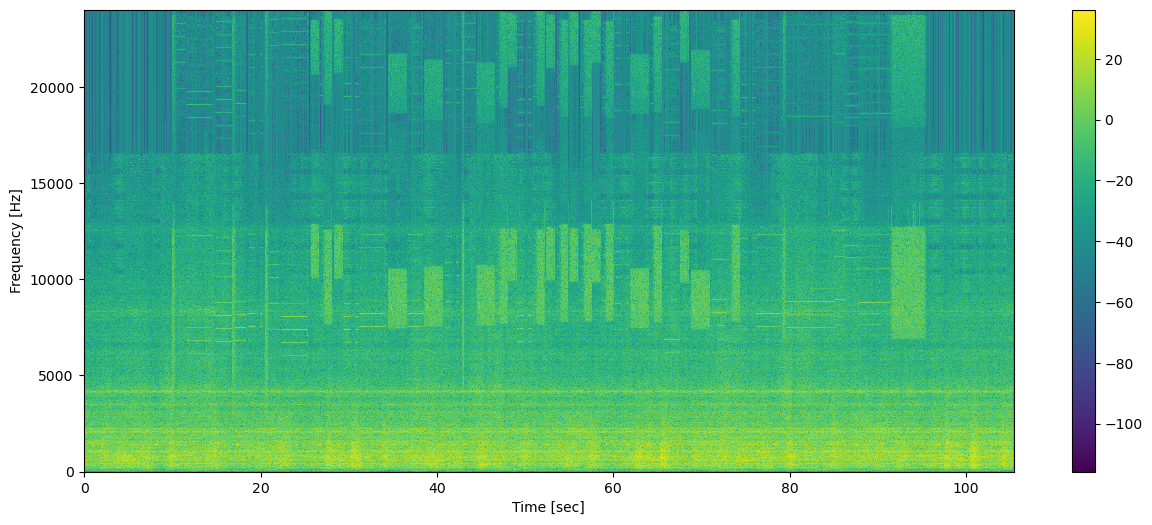

In [8]:
## FFT Parameters
win_type = "Taylor"
win_size = 4800  # Window size, 1000 to 4000 are ideal
overlap = 80 # Overlap %

# Determine step size and window type
hop_size = int(win_size*(1-overlap/100)) # Step/hop size
fs = 48000  # Your sampling frequency
if (win_type == "Hann"):
    win = signal.windows.hann(win_size) # Hann window
elif (win_type == "Taylor"):
    win = signal.windows.taylor(win_size, nbar=3, sll=25, norm=True) # Taylor window with parameters: nbar (2), sidelobe suppression level (-25)
elif (win_type == "Rect"):
    win = signal.windows.boxcar(win_size) # Rectangular window
elif (win_type == "Hamming"):
    win = signal.windows.hamming(win_size) # Rectangular window

## Generate Spectrogram (2D FFT)
SFT = signal.ShortTimeFFT(win, hop=hop_size, fs=fs) # Initialize ShortTimeFFT
Sx2 = SFT.spectrogram(l_ch) # Compute the spectrogram (absolute square of STFT)
Sx2[Sx2 == 0] = np.min(Sx2[np.nonzero(Sx2)]) # Substitute zeros with the minimum non-zero value to avoid log(0)
Sx2_dB = 10 * np.log10(Sx2) # Convert spectrogram to dB
t_min, t_max, f_min, f_max = SFT.extent(len(data), center_bins=True) # Get frequency and time boundaries
f_bins, t_bins = Sx2.shape # Get the number of frequency and time bins

# Plot the full spectrogram in dB
plt.figure(figsize=(15, 6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins), np.linspace(f_min, f_max, f_bins), Sx2_dB)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

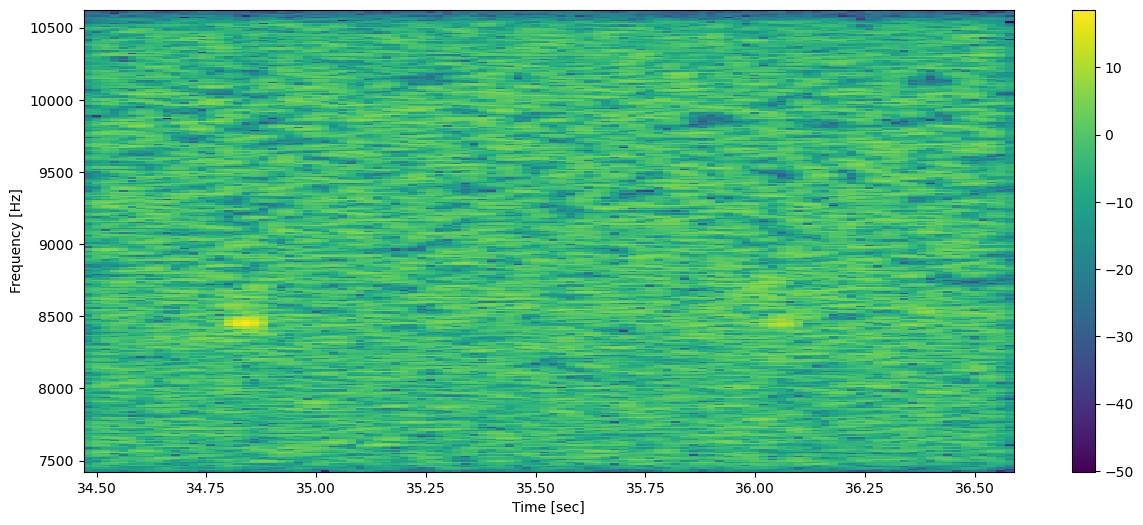

In [9]:
## Crop to signal G
# Frequency range
f_low = 7430  # Hz
f_high = 10630  # Hz
f_0 = int(f_low * f_bins / (f_max - f_min))
f_1 = int(f_high * f_bins / (f_max - f_min))

# Time range
t_start = 34.47
t_end = 36.59
t_0 = np.searchsorted(np.linspace(t_min, t_max, t_bins), t_start)
t_1 = np.searchsorted(np.linspace(t_min, t_max, t_bins), t_end)

# Crop the spectrogram to the selected frequency and time ranges
signal_spec = Sx2_dB[f_0:f_1, t_0:t_1]

# Plot the cropped spectrogram in dB
plt.figure(figsize=(15, 6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins)[t_0:t_1], np.linspace(f_min, f_max, f_bins)[f_0:f_1], signal_spec)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

In [10]:
# Save signal sample
signal_filename = '../signal_samples/G_signal_48k-' + str(win_size) + '-' + str(overlap) + '-' + win_type
np.savetxt(signal_filename + '.csv', signal_spec, delimiter=',')

(320, 106)

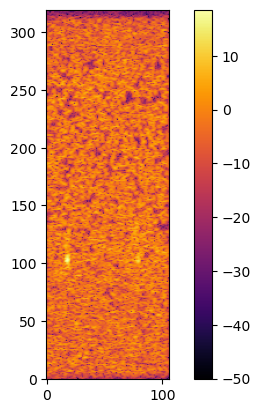

In [11]:
# Load signal sample
sig_sample = np.genfromtxt(signal_filename + '.csv', delimiter=',')

# Define end signal array
plt.imshow(sig_sample, origin='lower', cmap="inferno")
plt.colorbar()
sig_sample.shape
#plt.savefig(signal_filename + '.png')